<a href="https://colab.research.google.com/github/tembarenigoutham/Analysis/blob/main/TravClan_Set_C_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib-venn upsetplot

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=699dbb4e45015578ef9a99810fdc8fe0693ba974499a801c74cb0e91f8600c27
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from matplotlib_venn import venn3
from upsetplot import UpSet, from_memberships

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv(
    "hotel_bookings.csv",
    keep_default_na=False
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
0,100000,424,Customer_424,Group,2023-07-03,Manali,Platinum,38,Crimson Courtyard,Manali,...,4,OTA,5808.46,0.00,NONE,46467.68,Debit Card,Cancelled,,
1,100001,239,Customer_239,Individual,2022-07-18,Jaipur,None,32,Saffron Palace,Pune,...,4,Corporate Portal,4021.62,0.00,,16086.48,Net Banking,Cancelled,,
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,
3,100003,722,Customer_722,Individual,2022-11-07,Udaipur,None,43,Indigo Lodge,Bangalore,...,3,OTA,5885.85,0.00,NONE,17657.55,Credit Card,No-Show,,
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21


In [5]:
df.shape

(12000, 28)

In [6]:
df.columns.tolist()

['booking_id',
 'customer_id',
 'customer_name',
 'customer_segment',
 'customer_signup_date',
 'customer_home_city',
 'customer_loyalty_tier',
 'property_id',
 'property_name',
 'property_city',
 'property_star_rating',
 'property_type',
 'property_total_rooms',
 'booking_date',
 'checkin_date',
 'checkout_date',
 'room_type',
 'num_rooms',
 'nights',
 'booking_channel',
 'adr',
 'discount_amount',
 'coupon_code',
 'total_amount',
 'payment_method',
 'booking_status',
 'review_rating',
 'review_date']

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   booking_id             12000 non-null  int64  
 1   customer_id            12000 non-null  int64  
 2   customer_name          12000 non-null  object 
 3   customer_segment       12000 non-null  object 
 4   customer_signup_date   12000 non-null  object 
 5   customer_home_city     12000 non-null  object 
 6   customer_loyalty_tier  12000 non-null  object 
 7   property_id            12000 non-null  int64  
 8   property_name          12000 non-null  object 
 9   property_city          12000 non-null  object 
 10  property_star_rating   12000 non-null  int64  
 11  property_type          12000 non-null  object 
 12  property_total_rooms   12000 non-null  int64  
 13  booking_date           12000 non-null  object 
 14  checkin_date           12000 non-null  object 
 15  ch

In [8]:
# Convert date columns to datetime format

date_columns = [
    'customer_signup_date',
    'booking_date',
    'checkin_date',
    'checkout_date',
    'review_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Date conversion completed.")

Date conversion completed.


In [9]:
df[date_columns].dtypes

,0
customer_signup_date,datetime64[ns]
booking_date,datetime64[ns]
checkin_date,datetime64[ns]
checkout_date,datetime64[ns]
review_date,datetime64[ns]


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   booking_id             12000 non-null  int64         
 1   customer_id            12000 non-null  int64         
 2   customer_name          12000 non-null  object        
 3   customer_segment       12000 non-null  object        
 4   customer_signup_date   12000 non-null  datetime64[ns]
 5   customer_home_city     12000 non-null  object        
 6   customer_loyalty_tier  12000 non-null  object        
 7   property_id            12000 non-null  int64         
 8   property_name          12000 non-null  object        
 9   property_city          12000 non-null  object        
 10  property_star_rating   12000 non-null  int64         
 11  property_type          12000 non-null  object        
 12  property_total_rooms   12000 non-null  int64         
 13  b

In [11]:
# C1: Count bookings with zero rooms

zero_room_bookings = df[df['num_rooms'] == 0]

print("Number of bookings with num_rooms = 0:", len(zero_room_bookings))

Number of bookings with num_rooms = 0: 60


In [12]:
# Display the invalid bookings

zero_room_bookings.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
55,100055,723,Customer_723,Individual,2023-01-06,Goa,None,16,Banyan Residency,Delhi,...,3,OTA,2505.28,960.13,WELCOME,0.0,Debit Card,Completed,,NaT
101,100101,73,Customer_73,Group,2023-07-08,Chennai,None,40,Mango Lodge,Bangalore,...,2,Corporate Portal,9289.49,0.00,NONE,0.0,Debit Card,Completed,5.0,2024-06-14
372,100372,657,Customer_657,Individual,2023-12-08,Jaipur,Silver,7,Royal Orchid,Chennai,...,1,OTA,2369.62,0.00,,0.0,Net Banking,Cancelled,,NaT
385,100385,13,Customer_13,Individual,2023-11-25,Chennai,Silver,35,Maple Retreat,Bangalore,...,1,Travel Agent,8848.19,0.00,,0.0,UPI,Completed,5.0,2024-05-24
403,100403,447,Customer_447,Individual,2022-02-19,Kochi,Platinum,27,Saffron Residency,Pune,...,3,Travel Agent,5306.07,0.00,NONE,0.0,UPI,Cancelled,,NaT


In [13]:
# C2: Bookings made before customer signup

booking_before_signup = df[df['booking_date'] < df['customer_signup_date']]

print("Number of bookings before signup:", len(booking_before_signup))

Number of bookings before signup: 163


In [14]:
booking_before_signup[['booking_id',
                       'customer_id',
                       'customer_signup_date',
                       'booking_date']].head()

,booking_id,customer_id,customer_signup_date,booking_date
73,100073,1,2022-02-04,2021-10-22
154,100154,145,2023-10-17,2023-10-06
296,100296,565,2023-11-17,2023-11-03
361,100361,326,2023-12-21,2023-11-06
420,100420,293,2022-07-09,2022-03-23


In [15]:
# C3: Count bookings with no review

no_review = df[df['review_rating'].isna() | (df['review_rating'] == "")]

print("Bookings with no review:", len(no_review))

percentage = (len(no_review) / len(df)) * 100

print(f"Percentage of bookings with no review: {percentage:.2f}%")

Bookings with no review: 6854
Percentage of bookings with no review: 57.12%


In [16]:
# Review availability by booking status

review_status = (
    df.assign(
        has_review=~(df['review_rating'].isna() | (df['review_rating'] == ""))
    )
    .groupby('booking_status')
    .agg(
        Total_Bookings=('booking_id', 'count'),
        Reviews_Left=('has_review', 'sum')
    )
)

review_status['No_Review'] = (
    review_status['Total_Bookings'] - review_status['Reviews_Left']
)

review_status['No_Review_%'] = (
    review_status['No_Review']
    / review_status['Total_Bookings']
    * 100
).round(2)

review_status

,Total_Bookings,Reviews_Left,No_Review,No_Review_%
booking_status,,,,
Cancelled,2302,50,2252,97.83
Completed,9333,5096,4237,45.40
No-Show,365,0,365,100.00


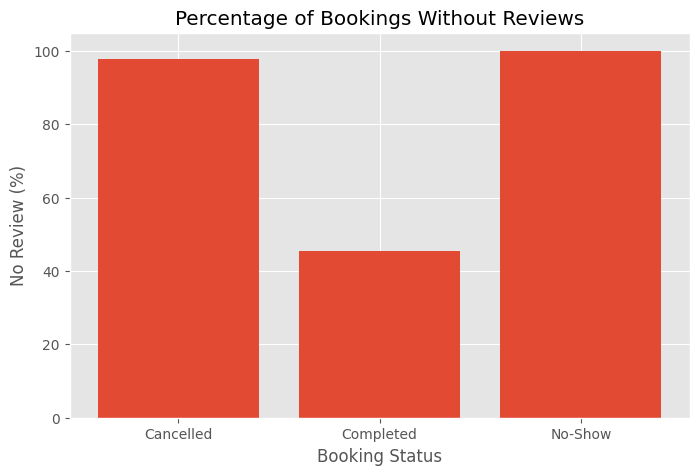

In [17]:
# Visualization

plt.figure(figsize=(8,5))

plt.bar(
    review_status.index,
    review_status['No_Review_%']
)

plt.title("Percentage of Bookings Without Reviews")
plt.xlabel("Booking Status")
plt.ylabel("No Review (%)")

plt.show()

In [18]:
# Section 2: Use only completed bookings

completed_df = df[df['booking_status'] == 'Completed'].copy()

print("Completed bookings:", len(completed_df))
completed_df.head()

Completed bookings: 9333


,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,nights,booking_channel,adr,discount_amount,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,3,Corporate Portal,17663.11,15373.35,SAVE10,90605.31,Net Banking,Completed,,NaT
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,7,Direct Website,6199.44,5924.82,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21
6,100006,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,37,Olive Lodge,Udaipur,...,2,OTA,3286.32,2625.92,WELCOME,10519.36,Debit Card,Completed,,NaT
7,100007,85,Customer_85,Individual,2022-07-25,Udaipur,None,45,Cedar Heights,Udaipur,...,2,Corporate Portal,4152.34,0.00,,8304.68,Credit Card,Completed,3.0,2024-07-13
8,100008,318,Customer_318,Individual,2023-06-10,Manali,Platinum,35,Maple Retreat,Bangalore,...,3,Corporate Portal,8795.64,2472.47,FEST15,23914.45,Credit Card,Completed,,NaT


In [19]:
# Number of unique customers

print("Unique customers:", completed_df['customer_id'].nunique())

Unique customers: 800


In [20]:
# VIP Definition 1: Total Spend

customer_spend = (
    completed_df
    .groupby('customer_id')
    .agg(
        total_spend=('total_amount', 'sum')
    )
    .reset_index()
)

customer_spend.head()

,customer_id,total_spend
0,1,102321.37
1,2,170558.80
2,3,277220.94
3,4,431885.00
4,5,425610.30


In [21]:
# Top 10% customers by total spend

top_10_count = int(customer_spend['customer_id'].nunique() * 0.10)

vip_spend = (
    customer_spend
    .sort_values(by='total_spend', ascending=False)
    .head(top_10_count)
)

print("Top 10% VIPs by Spend:", len(vip_spend))

vip_spend.head()

Top 10% VIPs by Spend: 80


,customer_id,total_spend
736,737,1939334.09
27,28,1566489.61
427,428,1563356.10
122,123,1549960.23
142,143,1503404.29


In [22]:
# VIP Definition 2: Booking Count

customer_bookings = (
    completed_df
    .groupby('customer_id')
    .agg(
        booking_count=('booking_id', 'count')
    )
    .reset_index()
)

customer_bookings.head()

,customer_id,booking_count
0,1,8
1,2,7
2,3,17
3,4,10
4,5,13


In [23]:
# Top 10% customers by booking count

vip_booking = (
    customer_bookings
    .sort_values(by='booking_count', ascending=False)
    .head(top_10_count)
)

print("Top 10% VIPs by Booking Count:", len(vip_booking))

vip_booking.head()

Top 10% VIPs by Booking Count: 80


,customer_id,booking_count
508,509,22
112,113,22
753,754,21
356,357,21
399,400,21


In [24]:
# Calculate months since signup

latest_booking = completed_df['booking_date'].max()

customer_ltv = (
    completed_df
    .groupby('customer_id')
    .agg(
        total_spend=('total_amount', 'sum'),
        signup_date=('customer_signup_date', 'first')
    )
    .reset_index()
)

customer_ltv['months_since_signup'] = (
    (latest_booking - customer_ltv['signup_date']).dt.days / 30
)

# Avoid division by zero
customer_ltv['months_since_signup'] = customer_ltv['months_since_signup'].replace(0, 1)

customer_ltv['ltv_rate'] = (
    customer_ltv['total_spend'] /
    customer_ltv['months_since_signup']
)

customer_ltv.head()

,customer_id,total_spend,signup_date,months_since_signup,ltv_rate
0,1,102321.37,2022-02-04,35.300000,2898.622380
1,2,170558.80,2023-04-18,20.700000,8239.555556
2,3,277220.94,2023-08-19,16.600000,16700.056627
3,4,431885.00,2023-11-29,13.200000,32718.560606
4,5,425610.30,2023-05-23,19.533333,21788.923208


In [25]:
# Top 10% customers by Lifetime Value Rate

vip_ltv = (
    customer_ltv
    .sort_values(by='ltv_rate', ascending=False)
    .head(top_10_count)
)

print("Top 10% VIPs by LTV Rate:", len(vip_ltv))

vip_ltv.head()

Top 10% VIPs by LTV Rate: 80


,customer_id,total_spend,signup_date,months_since_signup,ltv_rate
27,28,1566489.61,2023-12-17,12.600000,124324.572222
122,123,1549960.23,2023-09-11,15.833333,97892.225053
307,308,1253720.94,2023-11-25,13.333333,94029.070500
107,108,1104258.86,2023-12-18,12.566667,87872.057825
427,428,1563356.10,2023-05-08,20.033333,78037.742097


In [26]:
# Create sets of VIP customers

vip_spend_set = set(vip_spend['customer_id'])
vip_booking_set = set(vip_booking['customer_id'])
vip_ltv_set = set(vip_ltv['customer_id'])

print("Spend VIPs:", len(vip_spend_set))
print("Booking VIPs:", len(vip_booking_set))
print("LTV VIPs:", len(vip_ltv_set))

Spend VIPs: 80
Booking VIPs: 80
LTV VIPs: 80


In [27]:
# Overlap Analysis

all_three = vip_spend_set & vip_booking_set & vip_ltv_set

spend_booking = (vip_spend_set & vip_booking_set) - all_three
spend_ltv = (vip_spend_set & vip_ltv_set) - all_three
booking_ltv = (vip_booking_set & vip_ltv_set) - all_three

only_spend = vip_spend_set - vip_booking_set - vip_ltv_set
only_booking = vip_booking_set - vip_spend_set - vip_ltv_set
only_ltv = vip_ltv_set - vip_spend_set - vip_booking_set

print("Customers in all three:", len(all_three))
print("Customers in Spend & Booking only:", len(spend_booking))
print("Customers in Spend & LTV only:", len(spend_ltv))
print("Customers in Booking & LTV only:", len(booking_ltv))
print("Customers only in Spend:", len(only_spend))
print("Customers only in Booking:", len(only_booking))
print("Customers only in LTV:", len(only_ltv))

Customers in all three: 11
Customers in Spend & Booking only: 5
Customers in Spend & LTV only: 41
Customers in Booking & LTV only: 6
Customers only in Spend: 23
Customers only in Booking: 58
Customers only in LTV: 22


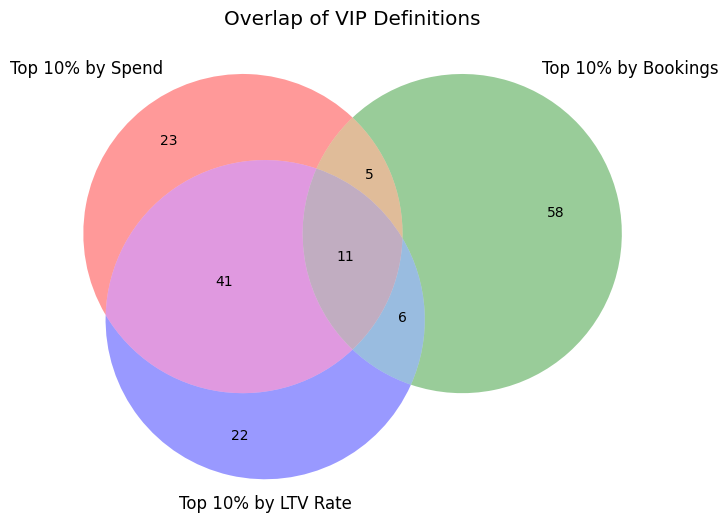

In [28]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

venn3(
    [vip_spend_set, vip_booking_set, vip_ltv_set],
    set_labels=(
        'Top 10% by Spend',
        'Top 10% by Bookings',
        'Top 10% by LTV Rate'
    )
)

plt.title("Overlap of VIP Definitions")
plt.show()

/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

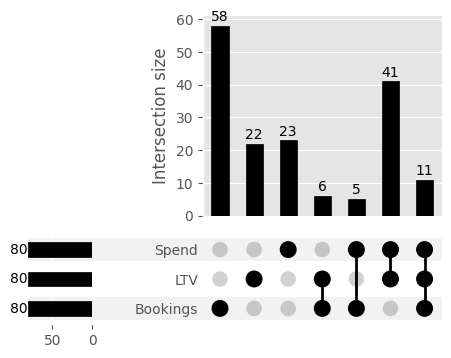

In [33]:
from upsetplot import UpSet

UpSet(data, subset_size='count', show_counts=True).plot()
plt.show()

In [34]:
# Use Spend-based VIP definition

completed_df['VIP'] = completed_df['customer_id'].isin(vip_spend_set)

completed_df[['customer_id', 'VIP']].head()

,customer_id,VIP
2,301,False
4,306,False
6,326,False
7,85,False
8,318,False


In [35]:
# Revenue generated by VIPs vs Non-VIPs

revenue_summary = (
    completed_df
    .groupby('VIP')
    .agg(
        Total_Revenue=('total_amount', 'sum')
    )
)

total_revenue = revenue_summary['Total_Revenue'].sum()

revenue_summary['Revenue_%'] = (
    revenue_summary['Total_Revenue']
    / total_revenue
    * 100
).round(2)

revenue_summary

,Total_Revenue,Revenue_%
VIP,,
False,2.157334e+08,73.16
True,7.912644e+07,26.84


In [36]:
# Add VIP label to the full dataset

df['VIP'] = df['customer_id'].isin(vip_spend_set)

cancellation = (
    df.groupby('VIP')
      .apply(lambda x: (x['booking_status'] == 'Cancelled').mean() * 100)
      .reset_index(name='Cancellation_Rate')
)

cancellation

/tmp/ipykernel_5989/1719583599.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['booking_status'] == 'Cancelled').mean() * 100)


,VIP,Cancellation_Rate
0,False,19.450178
1,True,17.064083


In [37]:
# Average discount amount

discount_summary = (
    completed_df
    .groupby('VIP')
    .agg(
        Avg_Discount=('discount_amount', 'mean')
    )
)

discount_summary

,Avg_Discount
VIP,
False,1464.798824
True,4167.122458


In [38]:
vip_summary = revenue_summary.merge(
    cancellation,
    on='VIP'
)

vip_summary = vip_summary.merge(
    discount_summary,
    on='VIP'
)

vip_summary

,VIP,Total_Revenue,Revenue_%,Cancellation_Rate,Avg_Discount
0,False,2.157334e+08,73.16,19.450178,1464.798824
1,True,7.912644e+07,26.84,17.064083,4167.122458


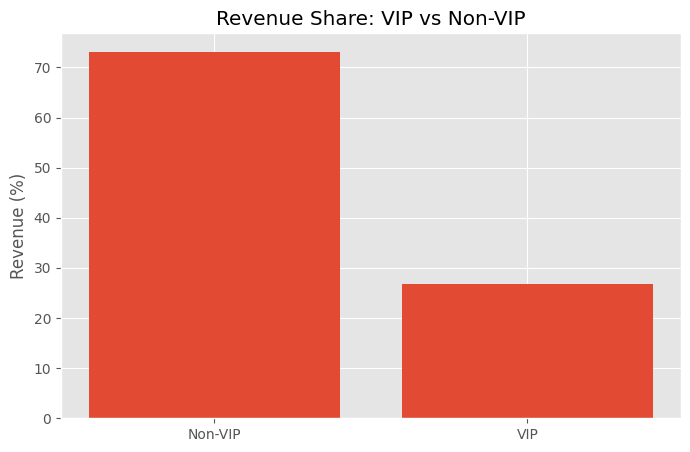

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    ['Non-VIP', 'VIP'],
    vip_summary['Revenue_%']
)

plt.title("Revenue Share: VIP vs Non-VIP")
plt.ylabel("Revenue (%)")
plt.show()

In [40]:
# -------------------------------
# C3: Acquisition Math
# -------------------------------

budget = 5000000          # ₹50 Lakhs
cac = 3000                # Cost to acquire one customer

new_customers = budget // cac

print("New Customers Acquired:", int(new_customers))

New Customers Acquired: 1666


In [41]:
# Average lifetime spend

customer_lifetime = (
    completed_df
    .groupby("customer_id")["total_amount"]
    .sum()
)

average_lifetime_spend = customer_lifetime.mean()

print("Average Lifetime Spend:", round(average_lifetime_spend,2))

Average Lifetime Spend: 368574.74


In [42]:
gross_lifetime_revenue = new_customers * average_lifetime_spend

print("Gross Lifetime Revenue")
print(round(gross_lifetime_revenue,2))

Gross Lifetime Revenue
614045516.03


In [43]:
year1_revenue = gross_lifetime_revenue * 0.20

print("Year 1 Revenue")
print(round(year1_revenue,2))

Year 1 Revenue
122809103.21


In [44]:
# -------------------------------
# C4: Retention Math
# -------------------------------

discount_cost = 500

customers_retained = budget // discount_cost

print("Customers that can be retained:", int(customers_retained))

Customers that can be retained: 10000


In [45]:
print("Actual Customers in Dataset:", completed_df["customer_id"].nunique())

coverage = (
    completed_df["customer_id"].nunique()
    / customers_retained
) * 100

print(f"Retention Capacity Coverage: {coverage:.2f}%")

Actual Customers in Dataset: 800
Retention Capacity Coverage: 8.00%


In [46]:
!pip install ipython-sql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 47.5 MB/s eta 0:00:00


In [47]:
%load_ext sql

In [48]:
%sql sqlite:///travclan.db

In [49]:
import sqlite3

conn = sqlite3.connect("travclan.db")

df.to_sql(
    "hotel_bookings",
    conn,
    if_exists="replace",
    index=False
)

print("Data Loaded Successfully!")

Data Loaded Successfully!


In [56]:
cursor = conn.cursor()

cursor.execute("SELECT COUNT(*) FROM hotel_bookings")

print(cursor.fetchone())

(12000,)


In [57]:
query = """
CREATE TABLE customers AS
SELECT DISTINCT
    customer_id,
    customer_name,
    customer_segment,
    customer_signup_date,
    customer_home_city,
    customer_loyalty_tier
FROM hotel_bookings;
"""

cursor.execute("DROP TABLE IF EXISTS customers")
cursor.execute(query)

conn.commit()

print("✅ Customers table created successfully!")

✅ Customers table created successfully!


In [58]:
query = """
CREATE TABLE properties AS
SELECT DISTINCT
    property_id,
    property_name,
    property_city,
    property_star_rating,
    property_type,
    property_total_rooms
FROM hotel_bookings;
"""

cursor.execute("DROP TABLE IF EXISTS properties")
cursor.execute(query)

conn.commit()

print("✅ Properties table created successfully!")

✅ Properties table created successfully!


In [59]:
query = """
CREATE TABLE bookings AS
SELECT
    booking_id,
    customer_id,
    property_id,
    booking_date,
    checkin_date,
    checkout_date,
    room_type,
    num_rooms,
    nights,
    booking_channel,
    adr,
    discount_amount,
    coupon_code,
    total_amount,
    payment_method,
    booking_status,
    review_rating,
    review_date
FROM hotel_bookings;
"""

cursor.execute("DROP TABLE IF EXISTS bookings")
cursor.execute(query)

conn.commit()

print("✅ Bookings table created successfully!")

✅ Bookings table created successfully!


In [60]:
tables = ["customers", "properties", "bookings"]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    count = cursor.fetchone()[0]
    print(f"{table}: {count} records")

customers: 800 records
properties: 60 records
bookings: 12000 records


In [61]:
query = """
WITH booking_sequence AS (

SELECT
    booking_id,
    customer_id,
    total_amount,

    ROW_NUMBER() OVER (
        PARTITION BY customer_id
        ORDER BY checkin_date
    ) AS booking_number

FROM bookings

WHERE booking_status='Completed'

)

SELECT

CASE
    WHEN booking_number = 1 THEN 'First Booking'
    WHEN booking_number = 2 THEN 'Second Booking'
    ELSE 'Third or Later'
END AS Booking_Sequence,

ROUND(AVG(total_amount),2) AS Average_Total_Amount,

COUNT(*) AS Number_of_Bookings

FROM booking_sequence

GROUP BY
CASE
    WHEN booking_number = 1 THEN 'First Booking'
    WHEN booking_number = 2 THEN 'Second Booking'
    ELSE 'Third or Later'
END;
"""

cursor.execute(query)

rows = cursor.fetchall()

import pandas as pd

pd.DataFrame(
    rows,
    columns=[
        "Booking Sequence",
        "Average Total Amount",
        "Number of Bookings"
    ]
)

,Booking Sequence,Average Total Amount,Number of Bookings
0,First Booking,33564.03,800
1,Second Booking,30784.82,799
2,Third or Later,31472.91,7734


In [62]:
query = """
SELECT

p.property_name,
p.property_city,

COUNT(*) AS Number_of_Reviews,

ROUND(

AVG(

CASE

WHEN b.review_rating='' THEN NULL

WHEN c.customer_segment='Corporate'

THEN CAST(b.review_rating AS REAL)/2.0

ELSE CAST(b.review_rating AS REAL)

END

),2) AS Normalized_Average_Rating

FROM bookings b

JOIN customers c
ON b.customer_id=c.customer_id

JOIN properties p
ON b.property_id=p.property_id

WHERE
b.review_rating!=''

GROUP BY
p.property_id,
p.property_name,
p.property_city

HAVING COUNT(*)>=20

ORDER BY
Normalized_Average_Rating DESC

LIMIT 5;
"""

cursor.execute(query)

rows = cursor.fetchall()

pd.DataFrame(
    rows,
    columns=[
        "Property",
        "City",
        "Reviews",
        "Normalized Rating"
    ]
)

,Property,City,Reviews,Normalized Rating
0,Hilltop Inn,Udaipur,99,3.92
1,Ivory Retreat,Jaipur,91,3.92
2,Indigo Lodge,Bangalore,96,3.92
3,Saffron Residency,Pune,100,3.91
4,Mango Lodge,Bangalore,76,3.91


In [64]:
import requests
import pandas as pd

In [65]:
url = "https://api.frankfurter.app/latest?base=INR&symbols=USD,EUR,GBP"

try:
    response = requests.get(url, timeout=10)
    response.raise_for_status()

    fx_data = response.json()

    print("API Connected Successfully!")
    print(fx_data)

except Exception as e:
    print("API Error:", e)

API Connected Successfully!
{'amount': 1.0, 'base': 'INR', 'date': '2026-06-19', 'rates': {'EUR': 0.00924, 'GBP': 0.00801, 'USD': 0.0106}}


In [66]:
rates = fx_data["rates"]

usd = rates["USD"]
eur = rates["EUR"]
gbp = rates["GBP"]

print("USD:", usd)
print("EUR:", eur)
print("GBP:", gbp)

USD: 0.0106
EUR: 0.00924
GBP: 0.00801


In [67]:
completed_df["Revenue_USD"] = completed_df["total_amount"] * usd
completed_df["Revenue_EUR"] = completed_df["total_amount"] * eur
completed_df["Revenue_GBP"] = completed_df["total_amount"] * gbp

completed_df.head()

,booking_id,customer_id,customer_name,customer_segment,customer_signup_date,customer_home_city,customer_loyalty_tier,property_id,property_name,property_city,...,coupon_code,total_amount,payment_method,booking_status,review_rating,review_date,VIP,Revenue_USD,Revenue_EUR,Revenue_GBP
2,100002,301,Customer_301,Corporate,2023-07-05,Jaipur,Gold,53,Saffron Heights,Chennai,...,SAVE10,90605.31,Net Banking,Completed,,NaT,False,960.416286,837.193064,725.748533
4,100004,306,Customer_306,Corporate,2022-02-02,Udaipur,Silver,29,Cedar Lodge,Kochi,...,SAVE10,80867.34,Credit Card,Completed,6.0,2024-11-21,False,857.193804,747.214222,647.747393
6,100006,326,Customer_326,Corporate,2023-12-21,Kochi,Gold,37,Olive Lodge,Udaipur,...,WELCOME,10519.36,Debit Card,Completed,,NaT,False,111.505216,97.198886,84.260074
7,100007,85,Customer_85,Individual,2022-07-25,Udaipur,None,45,Cedar Heights,Udaipur,...,,8304.68,Credit Card,Completed,3.0,2024-07-13,False,88.029608,76.735243,66.520487
8,100008,318,Customer_318,Individual,2023-06-10,Manali,Platinum,35,Maple Retreat,Bangalore,...,FEST15,23914.45,Credit Card,Completed,,NaT,False,253.493170,220.969518,191.554744


In [68]:
summary = pd.DataFrame({

"Currency":[
    "INR",
    "USD",
    "EUR",
    "GBP"
],

"Revenue":[
    completed_df["total_amount"].sum(),
    completed_df["Revenue_USD"].sum(),
    completed_df["Revenue_EUR"].sum(),
    completed_df["Revenue_GBP"].sum()
]

})

summary

,Currency,Revenue
0,INR,2.948598e+08
1,USD,3.125514e+06
2,EUR,2.724504e+06
3,GBP,2.361827e+06


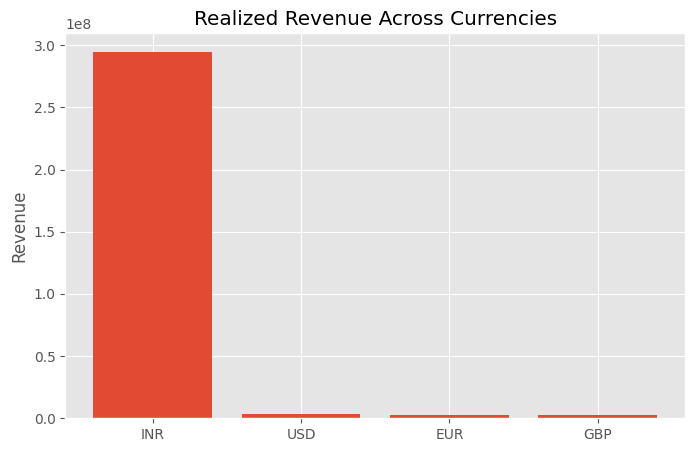

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    summary["Currency"],
    summary["Revenue"]
)

plt.title("Realized Revenue Across Currencies")

plt.ylabel("Revenue")

plt.show()

In [70]:
completed_df["Month"] = completed_df["booking_date"].dt.to_period("M").astype(str)

monthly = completed_df.groupby("Month")["total_amount"].sum().reset_index()

monthly

,Month,total_amount
0,2021-10,20542.57
1,2021-11,112489.90
2,2021-12,112073.50
3,2022-01,61254.07
4,2022-02,133000.69
5,2022-03,197592.43
6,2022-04,42994.83
7,2022-05,472773.01
8,2022-06,3897.98
9,2022-07,98309.91


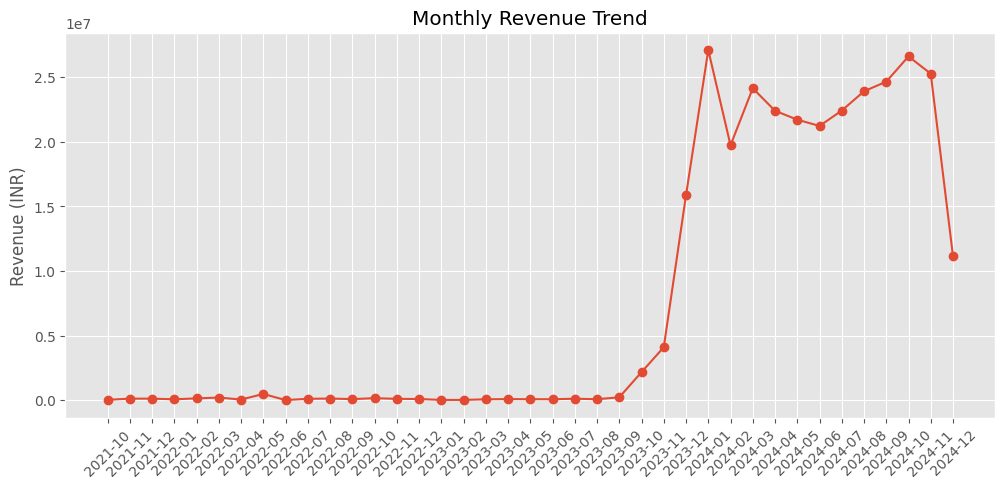

In [71]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Month"],
    monthly["total_amount"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue (INR)")

plt.show()